# Compare peak identification results with manual Sr peak identification by BSc students in 2023

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [12]:
# Load necessary packages
import matplotlib.pyplot as plt
import pandas as pd

# Load data

In [68]:
# Load growth interval data from Cleanalyze
Growth_interval_summary = pd.read_csv("Growth_intervals_summary_peakID.csv")
print(Growth_interval_summary.head())

# Load data from the manual growth counting and distance measurements in 2023
Peak_distance_data_2023 = pd.read_csv("Compare_manual_ID_2023/Peak_distance_2023.csv")
print(Peak_distance_data_2023.head())
Increment_counts_2023 = pd.read_csv("Compare_manual_ID_2023/Increment_counts_2023.csv")
print(Increment_counts_2023.head())

                           File    Interval    peakID  total_growth  \
0  B255_int_peakid.csv_peakID_1  interval 7  peakID_1    941.780751   
1  B255_int_peakid.csv_peakID_1  interval 6  peakID_1    968.719191   
2  B255_int_peakid.csv_peakID_1  interval 4  peakID_1   2658.435303   
3  B255_int_peakid.csv_peakID_1  interval 3  peakID_1   4132.759763   
4  B255_int_peakid.csv_peakID_1  interval 2  peakID_1   1561.556660   

   total_growth_centered  total_time_days  growth_rate  growth_rate_centered  \
0             941.780751        46.326088    20.329382             20.329382   
1             968.719191        27.988819    34.610934             34.610934   
2            2658.435303        26.194653   101.487709            101.487709   
3            4132.759763        26.916157   153.541967            153.541967   
4            1561.556660        20.165984    77.435184             77.435184   

            start_date             end_date  
0  2022-09-09 02:10:26  2022-10-25 10:00:00  


# Extract and reformat data for comparison

In [77]:
# Convert "File" column to specimen names
Growth_interval_summary['Specimen'] = Growth_interval_summary['File'].str[:4]

# Add treatment column based on file names
Growth_interval_summary['Treatment'] = Growth_interval_summary['File'].apply(
    lambda x: 'subtidal' if 'sub' in x else ('intertidal' if 'int' in x else 'none')
)

# Convert interval and peakID names to numeric values
Growth_interval_summary['Interval_numeric'] = Growth_interval_summary['Interval'].str.replace('interval ', '', regex=False).astype(int)
Growth_interval_summary['PeakID_numeric'] = Growth_interval_summary['peakID'].str.replace('peakID_', '', regex=False).astype(int)

# Lengthen the Peak_distance_data_2023 dataframe by melting it, ignoring Treatment column
Peak_distance_data_2023_long = Peak_distance_data_2023.drop('Treatment', axis=1).melt(id_vars=['Specimen', 'Researcher'], var_name='Interval_numeric', value_name='Total_growth_2023')
Peak_distance_data_2023_long['Interval_numeric'] = Peak_distance_data_2023_long['Interval_numeric'].astype(int)

# Merge the lengthened Peak_distance_data_2023 with Growth_interval_summary
Merged_data = pd.merge(Growth_interval_summary, Peak_distance_data_2023_long, on=['Specimen', 'Interval_numeric'], how='inner')
print(Merged_data.head())

                           File    Interval    peakID  total_growth  \
0  G652_sub_peakid.csv_peakID_1  interval 7  peakID_1    914.713074   
1  G652_sub_peakid.csv_peakID_1  interval 7  peakID_1    914.713074   
2  G652_sub_peakid.csv_peakID_1  interval 6  peakID_1    155.377928   
3  G652_sub_peakid.csv_peakID_1  interval 6  peakID_1    155.377928   
4  G652_sub_peakid.csv_peakID_1  interval 4  peakID_1   1990.668075   

   total_growth_centered  total_time_days  growth_rate  growth_rate_centered  \
0             914.713074        46.317674    19.748683             19.748683   
1             914.713074        46.317674    19.748683             19.748683   
2             155.377928        27.840000     5.581104              5.581104   
3             155.377928        27.840000     5.581104              5.581104   
4            1990.668075        26.181331    76.033876             76.033876   

            start_date             end_date Specimen Treatment  \
0  2022-09-09 02:22:33  20

# Plot comparison between total_growth (Cleanalyze) and Total_growth_2023 (manual) for all specimens with data for both methods

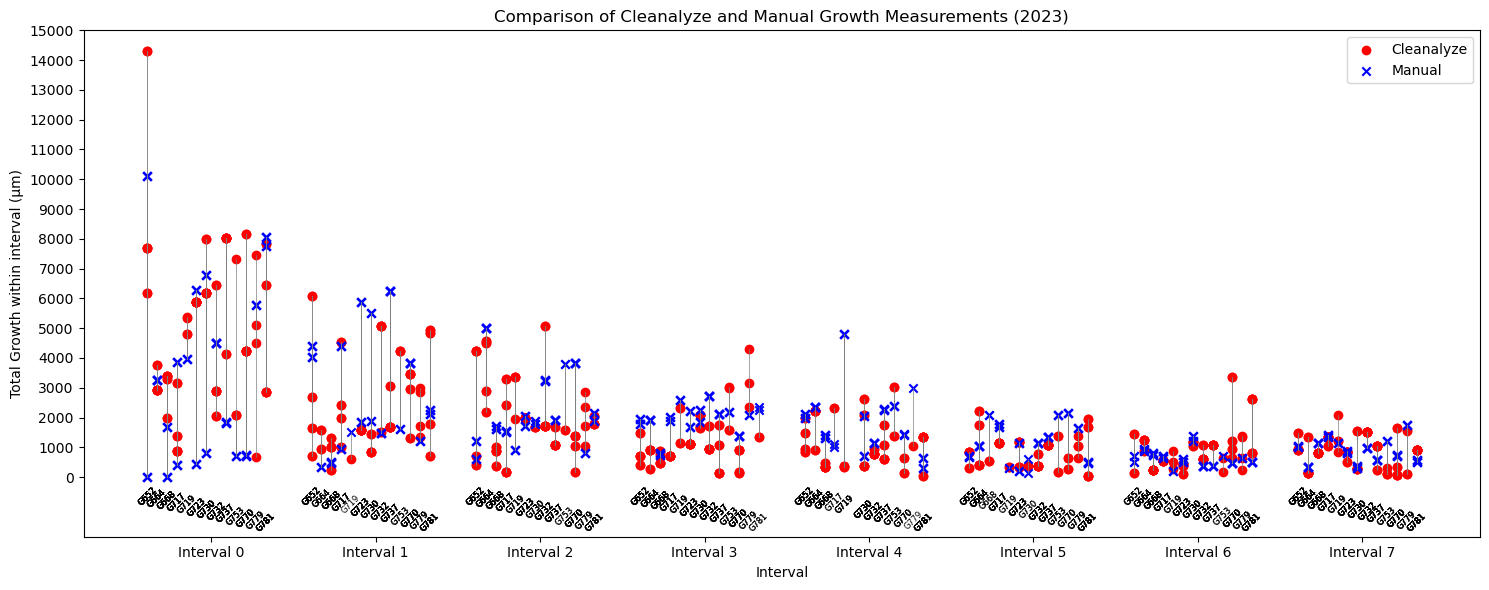

In [99]:
# Initialize a scatter plot comparing Cleanalyze and manual measurements, both colored by specimen and ordered on horizontally by Interval_numeric
plt.figure(figsize=(15, 6))

# Create jittering on x-axis to avoid overlap between specimens
jitter_amounts = {specimen: (i - len(Merged_data['Specimen'].unique()) / 2) * 0.06 for i, specimen in enumerate(Merged_data['Specimen'].unique())}

for specimen in Merged_data['Specimen'].unique():
    specimen_data = Merged_data[Merged_data['Specimen'] == specimen]
    plt.scatter(specimen_data['Interval_numeric'] + jitter_amounts[specimen], specimen_data['total_growth'], label="Cleanalyze", marker='o', color="red")
    plt.scatter(specimen_data['Interval_numeric'] + jitter_amounts[specimen], specimen_data['Total_growth_2023'], label="Manual", marker='x', color="blue")
    plt.plot([specimen_data['Interval_numeric'] + jitter_amounts[specimen], specimen_data['Interval_numeric'] + jitter_amounts[specimen]], # Connecting lines
             [specimen_data['total_growth'], specimen_data['Total_growth_2023']], color='gray', linestyle='-', linewidth=0.5)
    for interval in specimen_data['Interval_numeric']:
        plt.text(interval + jitter_amounts[specimen], -1000 - 75 * list(Merged_data['Specimen'].unique()).index(specimen),
                 specimen, fontsize=6, ha='center', va='bottom', rotation=45)

plt.xlabel('Interval')
plt.xticks(ticks=range(0, 8), labels= ["Interval " + str(i) for i in range(0, 8)])
plt.ylabel('Total Growth within interval (µm)')
plt.ylim(-2000, Merged_data[['total_growth', 'Total_growth_2023']].max().max() + 500)
plt.yticks(range(0, int(Merged_data[['total_growth', 'Total_growth_2023']].max().max() + 1000), 1000))
plt.title('Comparison of Cleanalyze and Manual Growth Measurements (2023)')
plt.legend(['Cleanalyze', 'Manual'])
plt.tight_layout()